In [6]:
import jax
import jax.numpy as jnp
import numpy as np

from functools import partial
from typing import NamedTuple
from tqdm.notebook import tqdm


LOSS_FN_MAPPING = {
    "mae": lambda y_true, y_pred: jnp.mean(jnp.abs(y_true - y_pred)),
    "mse": lambda y_true, y_pred: jnp.mean((y_true - y_pred) ** 2),
    "rmse": lambda y_true, y_pred: jnp.sqrt(jnp.mean((y_true - y_pred) ** 2))
}


class LinearParameters(NamedTuple):
    w: jnp.ndarray
    b: jnp.ndarray | None


def linear_model(params: LinearParameters, x: jnp.ndarray) -> jnp.ndarray:
    return jax.lax.cond(
        jnp.isnan(params.b),
        lambda: jnp.dot(x, params.w),
        lambda: jnp.dot(x, params.w) + params.b
    )


batched_linear_model = jax.vmap(linear_model, in_axes=(None, 0))


def loss_fn(loss_fn_arg, params: LinearParameters, x: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    preds = batched_linear_model(params, x)
    return loss_fn_arg(y, preds)


@partial(jax.jit, static_argnames=('loss_fn_arg', 'learning_rate', ))
def update(learning_rate, loss_fn_arg, params, x, y):
    grad_loss_fn = jax.value_and_grad(partial(loss_fn, loss_fn_arg))
    loss, grad = grad_loss_fn(params, x, y)

    return jax.tree.map(
        lambda p, g: p - g * learning_rate,
        params,
        grad
    ), loss


class BatchGenerator:

    def __init__(self, X, Y, batch_size):
        self.X = X
        self.Y = Y
        self.batch_size = batch_size
        self.num_batches = (X.shape[0] - 1) // batch_size + 1

    def __iter__(self):
        for i in range(self.num_batches):
            start = i * self.batch_size
            end = start + self.batch_size

            yield self.X[start:end], self.Y[start:end]


class LinearRegression:
    def __init__(
            self,
            use_bias: bool = True
    ):
        self.use_bias = use_bias
        self.params = None

    def fit(self, x: np.ndarray, y: np.ndarray, learning_rate: float = 0.01, **kwargs):
        loss = kwargs.get("loss", "mae")
        batch_size = kwargs.get("batch_size", 32)
        epochs = kwargs.get("epochs", 100)

        assert loss in LOSS_FN_MAPPING.keys(), f"loss must be one of {list(LOSS_FN_MAPPING.keys())}"

        number_of_features = x.shape[1]
        resolved_loss_fn = LOSS_FN_MAPPING[loss]

        batch_generator = BatchGenerator(x, y, batch_size)

        if self.use_bias:
            b = jnp.float32(1.0)
        else:
            b = jnp.nan

        w = jax.random.normal(jax.random.PRNGKey(42), (number_of_features,))

        self.params = LinearParameters(w, b)

        with tqdm(range(epochs), position=0) as pbar:

            for epoch in range(epochs):
                pbar.set_description(f"Epoch {epoch + 1}/{epochs}")

                for x_batch, y_batch in batch_generator:
                    self.params, loss_value = update(
                        learning_rate,
                        resolved_loss_fn,
                        self.params,
                        x_batch,
                        y_batch
                    )

                pbar.set_postfix({"loss": loss_value})
                pbar.update(1)

    def predict(self, x: np.ndarray) -> np.ndarray:
        assert self.params is not None, "Model not fitted yet"

        return batched_linear_model(self.params, jnp.asarray(x))

In [4]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



xs, ys, coef = make_regression(
    n_features=1,
    n_informative=1,
    n_targets=1,
    n_samples=10_000,
    noise=2,
    coef=True,
    bias=5
)

scaler = StandardScaler()
xs = scaler.fit_transform(xs)

x_train, x_test, y_train, y_test = train_test_split(xs, ys, test_size=0.2, random_state=42)

In [7]:
linear_regression = LinearRegression(use_bias=True)
linear_regression.fit(x_train, y_train, loss="mae", learning_rate=0.5, epochs=300, batch_size=512)


y_predictions = linear_regression.predict(x_test)
print(f"MAE: {mean_absolute_error(y_test, y_predictions)}")

  0%|          | 0/300 [00:00<?, ?it/s]

MAE: 1.5722911850779322


In [11]:
linear_regression.params

# coef = array(39.69681269)

LinearParameters(w=jnp.array([39.758873]
                             ), b=jnp.array(4.5382257))

LinearParameters(w=Array([39.758873], dtype=float32), b=Array(4.5382257, dtype=float32, weak_type=True))

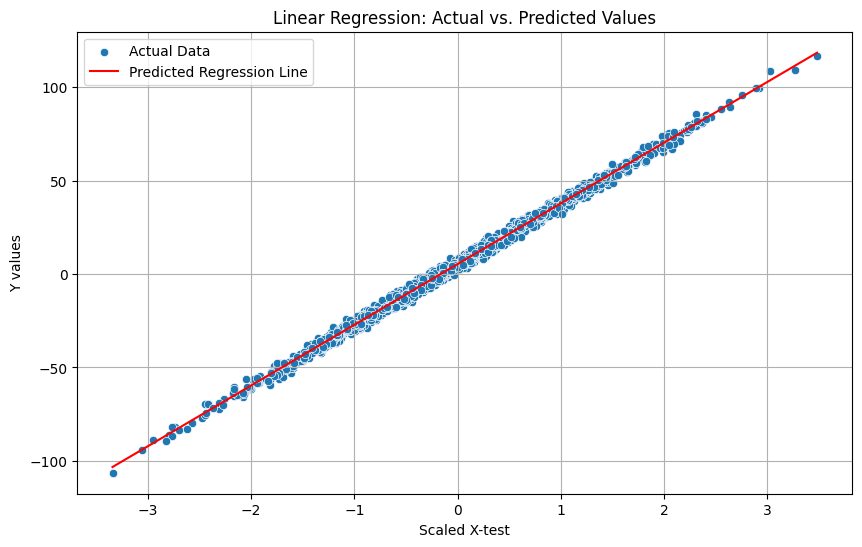

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of the test data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_test.flatten(), y=y_test, label='Actual Data')

# Plot the predicted regression line
sns.lineplot(x=x_test.flatten(), y=y_predictions, color='red', label='Predicted Regression Line')

plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Scaled X-test')
plt.ylabel('Y values')
plt.legend()
plt.grid(True)
plt.show()